# Network Science - UDD

## Procesos en redes: de la estructura a la dinámica - Práctica


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---


## Objetivos prácticos

1. simular SIR sobre distintas topologías;
2. comparar brotes sobre ER, WS y BA;
3. evaluar intervenciones:
   - random,
   - degree,
   - $k$-core;
4. explorar, opcionalmente, una representación temporal de contactos;
5. producir figuras y resultados que puedan alimentar:
   - el quiz,
   - el trabajo final,
   - la presentación de paper/tema.


## Hoja de ruta del práctico

La lógica del notebook es deliberadamente acumulativa:

1. construir tres topologías de referencia
2. inspeccionar diferencias estructurales básicas
3. correr una trayectoria `SIR` para fijar intuición visual
4. pasar a `Monte Carlo` para comparar resultados promedio
5. evaluar intervenciones bajo un presupuesto fijo
6. explorar, si hay tiempo, una transición empírica y un ejemplo temporal


## Alcance científico de este práctico

Este notebook ilustra regularidades bien conocidas en la literatura, pero no pretende estimar umbrales exactos ni reproducir un caso epidemiológico real.

Qué sí hace:

- comparar topologías con tamaño y grado medio comparables
- mostrar cómo cambian tamaño final, peak y duración al cambiar la estructura
- entrenar una comparación limpia entre estrategias de intervención

Qué no hace:

- validar una teoría exacta para cualquier red empírica
- inferir causalidad sustantiva a partir de una sola simulación
- decidir de forma universal si `degree` o `k`-core “ganan”



In [33]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)

## 1. Utilidades

### Qué deja listo este bloque

Al terminar esta parte deberías tener:

- un diccionario `nets` con tres redes sintéticas comparables en tamaño
- un resumen estructural mínimo para cada red
- una primera hipótesis sobre cuál debería facilitar brotes más grandes o más rápidos

En este diseño, las tres redes tienen tamaños parecidos y grado medio del mismo orden, pero difieren en aspectos que la literatura sí considera relevantes para difusión:

- heterogeneidad de grados
- clustering
- longitud efectiva de caminos
- presencia o ausencia de hubs

In [34]:
# Construcción de redes de ejemplo
def build_example_networks(n=400, seed=42):
    G_er = nx.erdos_renyi_graph(n, 0.02, seed=seed)
    G_ws = nx.watts_strogatz_graph(n, k=8, p=0.08, seed=seed)
    G_ba = nx.barabasi_albert_graph(n, m=4, seed=seed)
    return {"ER": G_er, "WS": G_ws, "BA": G_ba}

# Resumen estructural de cada red
def summarize_graph(G):
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    cc = nx.average_clustering(G)
    if nx.is_connected(G):
        apl = nx.average_shortest_path_length(G)
    else:
        giant_nodes = max(nx.connected_components(G), key=len)
        apl = nx.average_shortest_path_length(G.subgraph(giant_nodes))
    core = nx.core_number(G)
    return {
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),
        "k_mean": degrees.mean(),
        "k_max": degrees.max(),
        "clustering": cc,
        "apl_lcc": apl,
        "max_core": max(core.values()),
    }

nets = build_example_networks()
for name, G in nets.items():
    print(name, summarize_graph(G))

ER {'n': 400, 'm': 1579, 'k_mean': 7.895, 'k_max': 18.0, 'clustering': 0.02462601899734251, 'apl_lcc': 3.125728895102077, 'max_core': 5}
WS {'n': 400, 'm': 1600, 'k_mean': 8.0, 'k_max': 11.0, 'clustering': 0.5089770923520924, 'apl_lcc': 4.473082706766918, 'max_core': 6}
BA {'n': 400, 'm': 1584, 'k_mean': 7.92, 'k_max': 87.0, 'clustering': 0.06664315920354245, 'apl_lcc': 2.8449874686716794, 'max_core': 4}


## 2. Visualización rápida de topologías

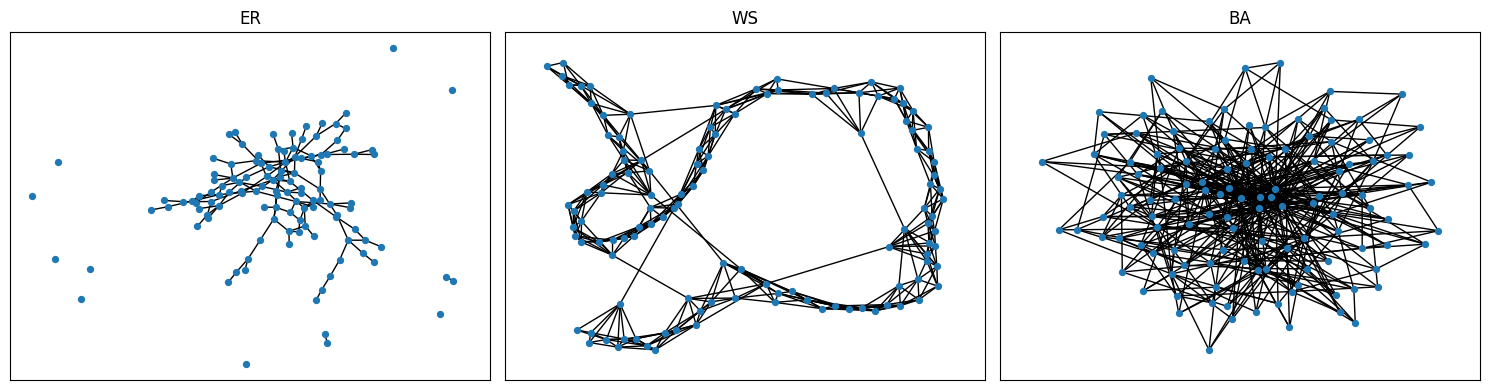

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, G) in zip(axes, nets.items()):
    H = G.subgraph(sorted(G.nodes())[:120]).copy()
    pos = nx.spring_layout(H, seed=3)
    nx.draw_networkx(H, pos=pos, node_size=18, with_labels=False, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 3. Simulador SIR discreto

### Supuestos exactos de esta implementación

Este simulador hace varias simplificaciones útiles:

- tiempo discreto
- actualización sincrónica por pasos
- transmisión binaria (Bernoulli) por enlace: en cada paso, un infectado contagia a un vecino susceptible con probabilidad `beta` (en cada paso de tiempo, para cada enlace entre un infectado y un susceptible, hacemos un "ensayo sí/no" con probabilidad beta de éxito de contagio.)
- recuperación con probabilidad `mu`
- red estática, no ponderada y no dirigida
- inmunidad permanente una vez que un nodo entra en `R`

Eso significa que el código no pretende reproducir un caso real con precisión. Sirve para aislar el efecto de la topología. 


In [ ]:
# Simulador SIR
def simulate_sir(G, beta=0.06, mu=0.25, seed_node=None, rng=None, max_steps=250):
    rng = np.random.default_rng() if rng is None else rng # para reproducibilidad
    nodes = list(G.nodes()) 
    if len(nodes) == 0:
        return {"S": [0], "I": [0], "R": [0], "final_size": 0, "peak_I": 0, "duration": 0} #manejo de caso extremo de red vacía
    if seed_node is None:
        seed_node = rng.choice(nodes) # si no se especifica, el nodo inicial se elige al azar

    state = {u: "S" for u in nodes} # todos empiezan como susceptibles
    state[seed_node] = "I" # el nodo semilla se infecta

    S_hist, I_hist, R_hist = [], [], [] # para almacenar la evolución temporal de cada estado

    ## Simulación paso a paso
    for t in range(max_steps): # iteramos hasta un máximo de pasos para evitar loops infinitos
        infected = [u for u in nodes if state[u] == "I"] # lista de nodos actualmente infectados
        susceptible = [u for u in nodes if state[u] == "S"] # lista de nodos actualmente susceptibles
        recovered = [u for u in nodes if state[u] == "R"] # lista de nodos actualmente recuperados

        S_hist.append(len(susceptible))
        I_hist.append(len(infected))
        R_hist.append(len(recovered))

        if len(infected) == 0: # si no hay infectados, la epidemia terminó
            break

        new_infected = set()
        new_recovered = set()

        for u in infected: # para cada nodo infectado, intentamos contagiar a sus vecinos susceptibles
            for v in G.neighbors(u): # iteramos sobre los vecinos de u
                if state[v] == "S" and rng.random() < beta: # si v es susceptible, intentamos contagiarlo con probabilidad beta
                    new_infected.add(v) # si el contagio es exitoso, agregamos v a la lista de nuevos infectados
            if rng.random() < mu: # cada nodo infectado tiene una probabilidad mu de recuperarse en cada paso
                new_recovered.add(u) # si u se recupera, agregamos u a la lista de nuevos recuperados

        for v in new_infected: # actualizamos el estado de los nuevos infectados a "I"
            if state[v] == "S": # solo cambiamos el estado si v todavía es susceptible (puede haber sido infectado por otro nodo en este mismo paso)
                state[v] = "I" # actualizamos el estado de v a "I"
        for u in new_recovered:# actualizamos el estado de los nuevos recuperados a "R"
            state[u] = "R"

    return {
        "S": S_hist,
        "I": I_hist,
        "R": R_hist,
        "final_size": R_hist[-1],
        "peak_I": max(I_hist),
        "duration": len(I_hist),
    }

## 4. Una trayectoria por topología

### Cómo interpretar una sola corrida

Una sola corrida sirve como **primera inspección** de la dinámica.

Permite:

* verificar que el simulador se comporte razonablemente;
* observar la forma general de `S(t)`, `I(t)` y `R(t)`;
* identificar diferencias gruesas entre topologías.

Pero **no alcanza** para comparar redes de manera rigurosa. Una trayectoria puede depender mucho del nodo inicial y del azar propio del proceso. Por eso, una sola corrida puede ser ilustrativa, pero no concluyente.

Si queremos comparar tamaños de brote, tiempos de propagación o efectos de intervención, el paso correcto es **repetir muchas simulaciones y promediar**.


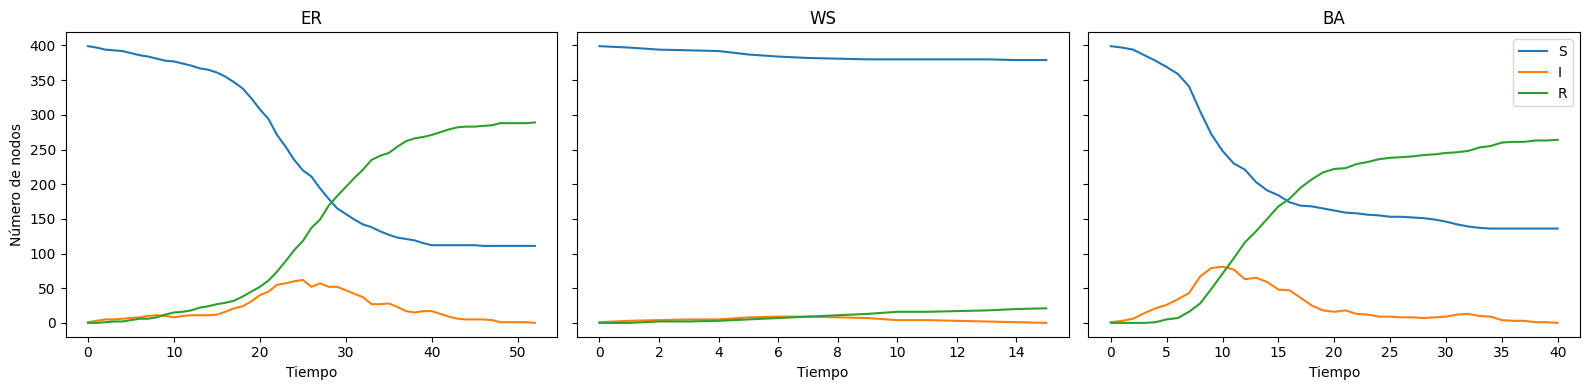

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, G) in zip(axes, nets.items()):
    out = simulate_sir(G, beta=0.07, mu=0.25, rng=np.random.default_rng(0))
    ax.plot(out["S"], label="S")
    ax.plot(out["I"], label="I")
    ax.plot(out["R"], label="R")
    ax.set_title(name)
    ax.set_xlabel("Tiempo")
axes[0].set_ylabel("Número de nodos")
axes[-1].legend()
plt.tight_layout()
plt.show()

Con los mismos parámetros, las trayectorias no son iguales entre topologías.

- En WS el brote es pequeño y se extingue rápido; en ER y sobre todo en BA la infección alcanza muchos más nodos.
- Aquí BA muestra una propagación más rápida y un pico de infectados más alto, consistente con el efecto de los hubs.

## 5. Monte Carlo: tamaño final y peak por topología

Una sola trayectoria puede engañar.  
Por eso repetimos muchas veces y promediamos.


Nota: **Monte Carlo** significa repetir muchas simulaciones aleatorias del mismo proceso y luego resumir los resultados, por ejemplo con promedios o distribuciones. Acá lo usamos porque una sola corrida puede ser atípica: al repetir muchas veces, estimamos de forma más estable el tamaño final del brote o el peak de infectados para cada topología.


ER
  final_mean    = 102.625
  final_std     = 124.783
  final_se      = 11.391
  final_ci95    = 22.326
  peak_mean     = 18.933
  peak_std      = 23.092
  peak_se       = 2.108
  peak_ci95     = 4.132
  duration_mean = 28.517
  duration_std  = 29.848
  duration_se   = 2.725
  duration_ci95 = 5.340

WS
  final_mean    = 23.033
  final_std     = 36.439
  final_se      = 3.326
  final_ci95    = 6.520
  peak_mean     = 5.392
  peak_std      = 5.441
  peak_se       = 0.497
  peak_ci95     = 0.973
  duration_mean = 22.442
  duration_std  = 25.259
  duration_se   = 2.306
  duration_ci95 = 4.519

BA
  final_mean    = 118.825
  final_std     = 124.238
  final_se      = 11.341
  final_ci95    = 22.229
  peak_mean     = 34.033
  peak_std      = 35.464
  peak_se       = 3.237
  peak_ci95     = 6.345
  duration_mean = 24.467
  duration_std  = 21.998
  duration_se   = 2.008
  duration_ci95 = 3.936



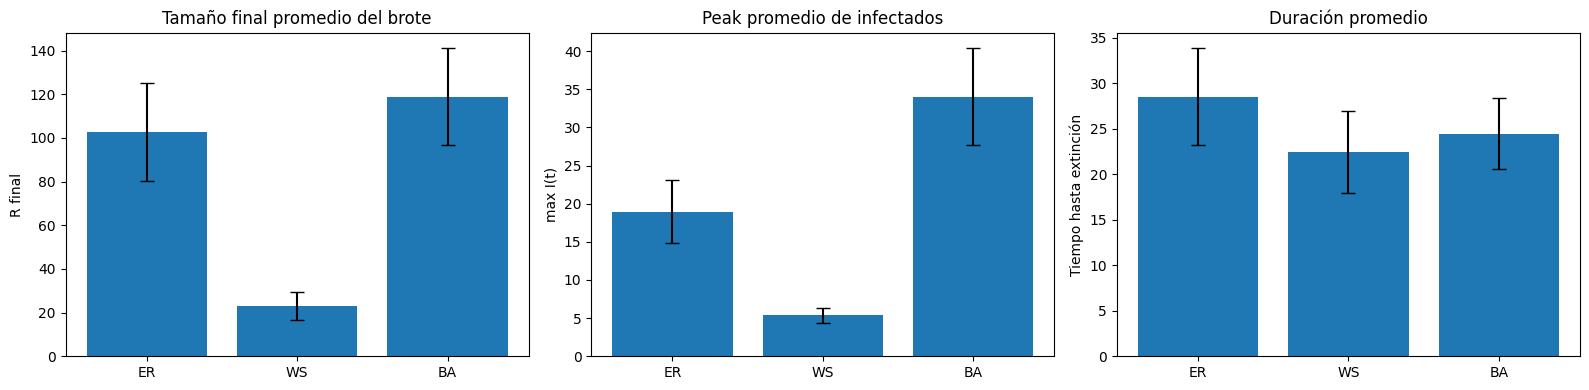

In [38]:
# Para obtener resultados más robustos, repetimos la simulación varias veces con 
# diferentes nodos semilla y promediamos los resultados. Esto es especialmente 
# importante para redes pequeñas, donde el nodo semilla puede tener un impacto 
# desproporcionado en la difusión.
def monte_carlo_sir(G, repeats=100, beta=0.06, mu=0.25, seed=123):
    # El argumento `seed` se usa para inicializar el generador de números aleatorios, 
    # asegurando que los resultados sean reproducibles. Cada repetición elige un nodo 
    # semilla diferente al azar y ejecuta la simulación SIR, almacenando los resultados 
    # en una lista.
    rng = np.random.default_rng(seed)  # para reproducibilidad
    out = []
    for _ in range(repeats):  # repetimos el proceso varias veces para obtener un promedio más robusto
        seed_node = rng.choice(list(G.nodes()))  # elegimos un nodo semilla al azar para cada repetición
        sim = simulate_sir(G, beta=beta, mu=mu, seed_node=seed_node, rng=rng)  # ejecutamos la simulación SIR
        out.append(sim)  # almacenamos los resultados de cada simulación en la lista `out`
    return out

# Para resumir los resultados de las múltiples simulaciones, calculamos estadísticas como 
# el tamaño final promedio del brote, el pico promedio de infectados y la duración promedio
# de la epidemia. Además de la media, calculamos:
# - la desviación estándar (`std`), que mide la dispersión entre corridas;
# - el error estándar (`se`), que mide la incertidumbre del promedio estimado;
# - un intervalo aproximado de confianza al 95% (`ci95`), usando 1.96 * se.
def summarize_runs(runs):
    final_sizes = np.array([r["final_size"] for r in runs], dtype=float)
    peaks = np.array([r["peak_I"] for r in runs], dtype=float)
    durations = np.array([r["duration"] for r in runs], dtype=float)

    def stats(x):
        mean = x.mean()
        std = x.std(ddof=1)
        se = std / np.sqrt(len(x))
        ci95 = 1.96 * se
        return mean, std, se, ci95

    final_mean, final_std, final_se, final_ci95 = stats(final_sizes)
    peak_mean, peak_std, peak_se, peak_ci95 = stats(peaks)
    duration_mean, duration_std, duration_se, duration_ci95 = stats(durations)

    return {
        "final_mean": final_mean,
        "final_std": final_std,
        "final_se": final_se,
        "final_ci95": final_ci95,
        "peak_mean": peak_mean,
        "peak_std": peak_std,
        "peak_se": peak_se,
        "peak_ci95": peak_ci95,
        "duration_mean": duration_mean,
        "duration_std": duration_std,
        "duration_se": duration_se,
        "duration_ci95": duration_ci95,
    }

# Ejecutamos Monte Carlo sobre cada topología de red ya guardada en `nets`.
# Aquí `nets` debiera ser un diccionario del tipo:
# nets = {"ER": G_er, "WS": G_ws, "BA": G_ba}
mc = {
    name: monte_carlo_sir(G, repeats=120, beta=0.06, mu=0.25, seed=10)
    for name, G in nets.items()
}

# Resumimos todas las corridas
summaries = {name: summarize_runs(runs) for name, runs in mc.items()}

# Mostramos resultados numéricos
for name, stats in summaries.items():
    print(name)
    print(f"  final_mean    = {stats['final_mean']:.3f}")
    print(f"  final_std     = {stats['final_std']:.3f}")
    print(f"  final_se      = {stats['final_se']:.3f}")
    print(f"  final_ci95    = {stats['final_ci95']:.3f}")
    print(f"  peak_mean     = {stats['peak_mean']:.3f}")
    print(f"  peak_std      = {stats['peak_std']:.3f}")
    print(f"  peak_se       = {stats['peak_se']:.3f}")
    print(f"  peak_ci95     = {stats['peak_ci95']:.3f}")
    print(f"  duration_mean = {stats['duration_mean']:.3f}")
    print(f"  duration_std  = {stats['duration_std']:.3f}")
    print(f"  duration_se   = {stats['duration_se']:.3f}")
    print(f"  duration_ci95 = {stats['duration_ci95']:.3f}")
    print()

# Extraemos medias e intervalos de confianza para graficar
labels = list(mc.keys())

final_means = [summaries[name]["final_mean"] for name in labels]
final_errs = [summaries[name]["final_ci95"] for name in labels]

peak_means = [summaries[name]["peak_mean"] for name in labels]
peak_errs = [summaries[name]["peak_ci95"] for name in labels]

duration_means = [summaries[name]["duration_mean"] for name in labels]
duration_errs = [summaries[name]["duration_ci95"] for name in labels]

# Graficamos las tres métricas principales:
# - tamaño final promedio del brote
# - peak promedio de infectados
# - duración promedio de la epidemia
#
# Las barras de error muestran un intervalo aproximado de confianza al 95% del promedio,
# no la dispersión total entre corridas. Eso hace la comparación entre topologías más clara.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].bar(labels, final_means, yerr=final_errs, capsize=5)
axes[0].set_title("Tamaño final promedio del brote")
axes[0].set_ylabel("R final")

axes[1].bar(labels, peak_means, yerr=peak_errs, capsize=5)
axes[1].set_title("Peak promedio de infectados")
axes[1].set_ylabel("max I(t)")

axes[2].bar(labels, duration_means, yerr=duration_errs, capsize=5)
axes[2].set_title("Duración promedio")
axes[2].set_ylabel("Tiempo hasta extinción")

plt.tight_layout()
plt.show()

Al promediar muchas corridas, aparece un patrón más estable: **WS** genera brotes mucho más pequeños, con picos más bajos y menor duración promedio. **ER** y, sobre todo, **BA** permiten una difusión más amplia.

En esta simulación, **BA** produce el mayor tamaño final y el mayor peak de infectados, consistente con el papel de los hubs en acelerar y amplificar la propagación. En cambio, **ER** muestra la mayor duración promedio, sugiriendo una difusión menos explosiva pero más sostenida en el tiempo.


### Preguntas

1. ¿Cambiaría la conclusión si bajamos $\beta$?
    - **Sí, podría cambiar.** Si bajamos $\beta$, el contagio se vuelve menos eficiente y las diferencias entre topologías pueden achicarse o incluso desaparecer si el proceso queda bajo el umbral.
2. ¿Qué rol parece jugar la heterogeneidad de grado?
    -  **La heterogeneidad de grado parece clave.** En redes con hubs, como BA, unos pocos nodos concentran muchas conexiones y facilitan brotes más grandes y picos más altos.


### Qué conviene reportar al comparar topologías

Si quieres que la comparación sea defendible, reporta al menos:

- media y dispersión del tamaño final del brote
- media del `peak` de infectados
- duración promedio del proceso
- una nota sobre si la diferencia parece robusta o sensible a la semilla

Si dos topologías tienen medias parecidas pero una varianza mucho mayor, eso también es información relevante: la red puede no cambiar mucho el promedio, pero sí la predictibilidad del brote.


## 6. Intervenciones: random vs degree vs $k$-core

### Regla para comparar intervenciones de manera justa

Una comparación entre estrategias solo es limpia si mantienes constante:

- la fracción inmunizada
- el proceso dinámico (`beta` prob contagio, `mu`prob recuperado)
- el número de repeticiones
- el criterio de evaluación

Además, recuerda que al remover nodos cambias el tamaño y la conectividad de la red. Por eso conviene comparar siempre contra un baseline explícito y, cuando sea posible, reportar reducción relativa además del valor absoluto.


In [53]:
# Para comparar estrategias de inmunización, definimos funciones para elegir nodos al azar, 
# por grado o por k-core. Luego, la función `immunize` toma una red y una estrategia, 
# remueve los nodos seleccionados y devuelve la red modificada junto con la lista de 
# nodos removidos.

# Para elegir nodos al azar, usamos `numpy.random.choice` para seleccionar una fracción 
# de nodos sin reemplazo.
def choose_nodes_random(G, frac=0.1, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    nodes = list(G.nodes())
    k = max(1, int(frac * len(nodes)))
    return list(rng.choice(nodes, size=k, replace=False))

# Para elegir nodos por grado, ordenamos los nodos por su grado de manera descendente 
# y seleccionamos el top `k`, donde `k` es la cantidad de nodos a inmunizar según la 
# fracción especificada.
def choose_nodes_degree(G, frac=0.1):
    k = max(1, int(frac * G.number_of_nodes()))
    return [u for u, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:k]]


# Para elegir nodos por k-core, calculamos el número de core para cada nodo y seleccionamos
# el top `k` de nodos con mayor número de core, donde `k` es la cantidad de nodos a inmunizar 
# según la fracción especificada.
def choose_nodes_kcore(G, frac=0.1):
    core = nx.core_number(G)
    k = max(1, int(frac * G.number_of_nodes()))
    return [u for u, _ in sorted(core.items(), key=lambda x: x[1], reverse=True)[:k]]

# La función `immunize` toma una red y una estrategia de inmunización, selecciona los 
# nodos a inmunizar
def immunize(G, strategy="random", frac=0.1, rng=None):
    if strategy == "random":
        nodes = choose_nodes_random(G, frac=frac, rng=rng)
    elif strategy == "degree":
        nodes = choose_nodes_degree(G, frac=frac)
    elif strategy == "kcore":
        nodes = choose_nodes_kcore(G, frac=frac)
    else:
        raise ValueError("Estrategia no soportada")
    H = G.copy()
    H.remove_nodes_from(nodes)
    return H, nodes

In [54]:
# Para evaluar el impacto de las intervenciones, ejecutamos Monte Carlo SIR sobre la red original
# y sobre las redes modificadas por cada estrategia de inmunización. Luego, resumimos los 
# resultados y los comparamos con el caso base sin intervención. Esto nos permite ver cómo 
# cada estrategia reduce el tamaño final del brote, el pico de infectados y la duración de la 
# epidemia en comparación con el caso sin intervención.
def evaluate_interventions(G, frac_list=(0.02, 0.05, 0.1, 0.15, 0.2), repeats=100, beta=0.06, mu=0.25, seed=100):
    rng = np.random.default_rng(seed)
    results = defaultdict(list)

    baseline = summarize_runs(monte_carlo_sir(G, repeats=repeats, beta=beta, mu=mu, seed=seed))["final_mean"]

    for frac in frac_list:
        results["frac"].append(frac)
        results["baseline"].append(baseline)
        for strategy in ["random", "degree", "kcore"]:
            H, _ = immunize(G, strategy=strategy, frac=frac, rng=rng)
            final_mean = summarize_runs(monte_carlo_sir(H, repeats=repeats, beta=beta, mu=mu, seed=seed))["final_mean"]
            results[strategy].append(final_mean)
    return results

G_target = nets["BA"]
interv = evaluate_interventions(G_target, repeats=80, beta=0.06, mu=0.25)
interv

defaultdict(list,
            {'frac': [0.02, 0.05, 0.1, 0.15, 0.2],
             'baseline': [142.975, 142.975, 142.975, 142.975, 142.975],
             'random': [137.45, 105.275, 102.3375, 90.35, 79.725],
             'degree': [41.5625, 20.5375, 3.3875, 2.5, 2.0375],
             'kcore': [94.125, 29.2625, 4.8125, 3.175, 2.5375]})

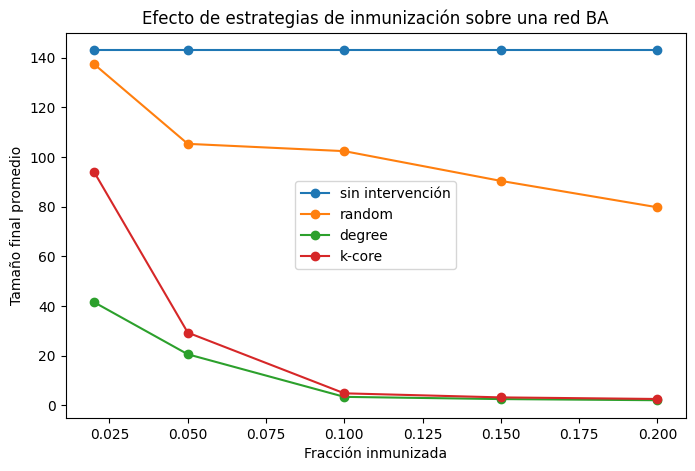

In [55]:
plt.figure(figsize=(8,5))
plt.plot(interv["frac"], interv["baseline"], marker="o", label="sin intervención")
plt.plot(interv["frac"], interv["random"], marker="o", label="random")
plt.plot(interv["frac"], interv["degree"], marker="o", label="degree")
plt.plot(interv["frac"], interv["kcore"], marker="o", label="k-core")
plt.xlabel("Fracción inmunizada")
plt.ylabel("Tamaño final promedio")
plt.title("Efecto de estrategias de inmunización sobre una red BA")
plt.legend()
plt.show()

En esta red BA, inmunizar nodos al azar reduce poco el tamaño final del brote, incluso cuando aumenta la fracción inmunizada. En cambio, las estrategias dirigidas son mucho más efectivas: 

- priorizar por grado produce la caída más fuerte y rápida
- mientras que k-core también reduce sustancialmente el brote, aunque aquí queda por encima de degree para fracciones bajas e intermedias. 

La lección es: en redes heterogéneas, a quién inmunizamos importa mucho más que inmunizar al azar.

Esto es consistente con parte de la literatura sobre nodos influyentes e intervención (por ejemplo, Kitsak et al., 2010), pero los benchmarks comparativos también muestran que **no existe un ganador universal** para todos los procesos y todas las métricas (Bramson et al., 2016).

En este notebook, como el proceso es `SIR` y la métrica principal es **tamaño final promedio**, es razonable esperar que `degree` rinda muy bien en redes tipo BA. Eso sería un resultado **contingente al proceso y al criterio de evaluación**, no una ley general.

### Extensión recomendada en casa

Repite este experimento en:
- ER,
- WS,
- una red real


## 7. Opcional: explorar el umbral con una grilla de parámetros

Esto no estima un umbral analítico exacto, pero sí ayuda a ver una transición empírica.

### Qué sí y qué no muestra esta grilla

Esta exploración sirve para ubicar una zona de transición empírica, no para estimar un umbral exacto con pretensión teórica.

Sí muestra:

- dónde el brote deja de ser sistemáticamente pequeño
- si la topología parece hacer más fácil o difícil la difusión
- si la curva crece suave o abruptamente

No muestra por sí sola:

- el umbral asintótico verdadero
- qué aproximación analítica explica mejor la curva
- qué pasaría si cambias el tamaño de la red o el modelo microscópico


<k> = 7.9200
<k^2> = 125.4500
lambda_1(A) = 15.1755
lambda_c^HMF ≈ 0.0631
lambda_c^QMF ≈ 0.0659


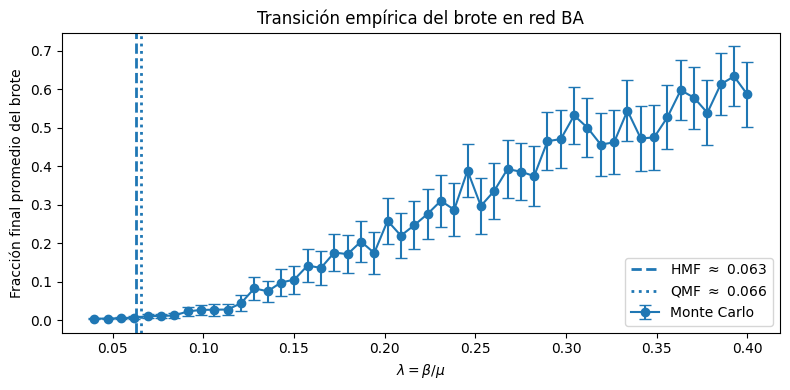

In [57]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Red objetivo
# -----------------------------
G = nets["BA"]

# -----------------------------
# Umbrales aproximados HMF y QMF
# -----------------------------
degrees = np.array([d for _, d in G.degree()], dtype=float)
k_mean = degrees.mean()
k2_mean = np.mean(degrees**2)

A = nx.to_numpy_array(G, dtype=float) # matriz de adyacencia de la red
lambda1 = max(np.linalg.eigvalsh(A)) # valor propio máximo de la matriz de adyacencia

lambda_hmf = k_mean / k2_mean # umbral aproximado según HMF
lambda_qmf = 1 / lambda1 # umbral aproximado según QMF

print(f"<k> = {k_mean:.4f}")
print(f"<k^2> = {k2_mean:.4f}")
print(f"lambda_1(A) = {lambda1:.4f}")
print(f"lambda_c^HMF ≈ {lambda_hmf:.4f}")
print(f"lambda_c^QMF ≈ {lambda_qmf:.4f}")

# -----------------------------
# Grilla de parámetros
# -----------------------------
betas = np.linspace(0.01, 0.1, 50)
mu = 0.25

final_means = []
final_errs = []

for beta in betas:
    runs = monte_carlo_sir(G, repeats=80, beta=beta, mu=mu, seed=22)
    stats = summarize_runs(runs)
    final_means.append(stats["final_mean"] / G.number_of_nodes())
    final_errs.append(stats["final_ci95"] / G.number_of_nodes())

lambdas = betas / mu

# -----------------------------
# Figura
# -----------------------------
plt.figure(figsize=(8, 4))
plt.errorbar(lambdas, final_means, yerr=final_errs, marker="o", capsize=4, label="Monte Carlo")
plt.axvline(lambda_hmf, linestyle="--", linewidth=2, label=fr"HMF $\approx$ {lambda_hmf:.3f}")
plt.axvline(lambda_qmf, linestyle=":", linewidth=2, label=fr"QMF $\approx$ {lambda_qmf:.3f}")

plt.xlabel(r"$\lambda = \beta/\mu$")
plt.ylabel("Fracción final promedio del brote")
plt.title("Transición empírica del brote en red BA")
plt.legend()
plt.tight_layout()
plt.show()

La simulación muestra una **transición empírica** en el tamaño final del brote.

Los umbrales que aparecen en la figura representan un **valor crítico aproximado de** $ \lambda = \beta/\mu $, a partir del cual la infección deja de producir brotes pequeños y empieza a poder sostener brotes grandes sobre la red. En otras palabras, separan un régimen en que la difusión típicamente se apaga rápido de otro en que puede alcanzar una fracción macroscópica de la red.

Más concretamente:

* $ \beta $: probabilidad de contagio por contacto y por paso de tiempo
* $ \mu $: probabilidad de recuperación por paso
* $ \lambda = \beta/\mu $: fuerza relativa del contagio frente a la recuperación

Entonces, el umbral responde a la siguiente pregunta:

> **¿cuán contagioso debe ser el proceso, en relación con la recuperación, para que la red permita brotes grandes?**

Es importante no sobreinterpretar este número. En el mundo real, no es un “umbral de la enfermedad” en abstracto. Depende al mismo tiempo de:

* la dinámica epidemiológica del modelo, a través de $ \beta $ y $ \mu $
* y la topología de la red de contactos

Por eso, el mensaje correcto es este:

> El umbral no es una propiedad aislada de la enfermedad, sino una propiedad del **proceso epidémico sobre una red dada y bajo un modelo dado**.

En la figura, para valores muy bajos de $ \lambda $, la infección casi siempre se apaga rápido y la fracción final infectada es cercana a cero. A medida que $ \lambda $ aumenta, el brote empieza a alcanzar una fracción cada vez mayor de la red, hasta volverse macroscópico.

Las aproximaciones **HMF** y **QMF** ubican el umbral cerca de $ \lambda_c \approx 0.06\text{–}0.07 $, y la curva de Monte Carlo comienza efectivamente a despegar en esa vecindad. Como la red es finita, la transición no aparece como un salto perfectamente abrupto, sino como un cambio gradual. Por eso la curva crece de manera suave y no como una discontinuidad ideal.

> **En síntesis:** los proxies teóricos entregan una escala razonable del umbral, y la simulación muestra que, al superar ese rango, la red BA pasa de brotes pequeños a brotes grandes.



## 8. Opcional: red temporal vs red agregada

Aquí construimos una secuencia simple de contactos con timestamps y la comparamos con su versión agregada. La pregunta no es solo quién está conectado con quién, sino también en qué orden ocurrieron los contactos.

En una red temporal, un camino solo sirve para difusión si respeta la flecha del tiempo: no basta con que exista topológicamente, también debe existir en el orden correcto. Por eso, la red agregada puede sugerir trayectorias que en realidad nunca estuvieron disponibles como rutas causales de propagación.
Aquí armamos una secuencia simple de contactos con timestamps y comparamos una difusión temporal con la difusión en la red agregada.

Accesibilidad temporal desde 0: {0: -1, 1: 0, 2: 1, 3: 2, 4: 3, 5: 11, 6: 12}
Accesibilidad agregada desde 0: {0: 0, 1: 1, 4: 1, 2: 2, 3: 2, 5: 2, 6: 3}


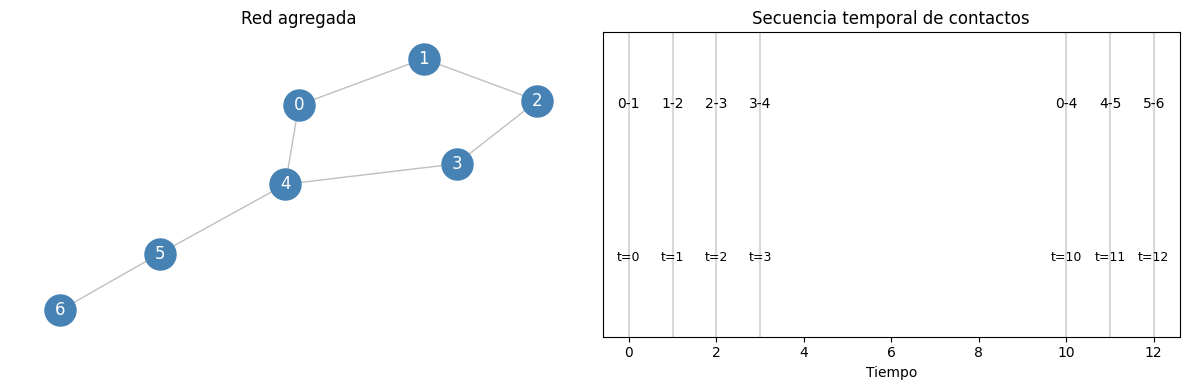

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Cada tupla es (u, v, t): contacto entre u y v en el tiempo t
temporal_edges = [
    (0, 1, 0),
    (1, 2, 1),
    (2, 3, 2),
    (3, 4, 3),
    (0, 4, 10),
    (4, 5, 11),
    (5, 6, 12),
]

# -----------------------------
# 1. Red agregada
# -----------------------------
G_agg = nx.Graph()
G_agg.add_edges_from((u, v) for u, v, t in temporal_edges)

# -----------------------------
# 2. Accesibilidad temporal
# -----------------------------
def temporal_reachable(edges, source=0, start_time=-1):
    """
    Calcula el primer tiempo al que cada nodo puede ser alcanzado
    desde 'source', respetando el orden temporal de los contactos.
    """
    reached = {source: start_time}

    for u, v, t in sorted(edges, key=lambda x: x[2]):
        # Si ya podía estar en u antes de t, puedo pasar a v en t
        if u in reached and reached[u] <= t and v not in reached:
            reached[v] = t
        # Como aquí tratamos los contactos como no dirigidos:
        if v in reached and reached[v] <= t and u not in reached:
            reached[u] = t

    return reached

# Calculamos la accesibilidad temporal desde el nodo 0, asumiendo que el proceso 
# comienza en el tiempo -1 (antes de cualquier contacto).
temporal_reach = temporal_reachable(temporal_edges, source=0, start_time=-1)

# -----------------------------
# 3. Accesibilidad agregada
# -----------------------------
agg_reach = nx.single_source_shortest_path_length(G_agg, 0)

# entega el tiempo en que alcanza cada nodo, considerando el orden temporal de los contactos
print("Accesibilidad temporal desde 0:", temporal_reach)
# entrega la distancia mínima en la red agregada, sin considerar tiempos
print("Accesibilidad agregada desde 0:", agg_reach) 

# -----------------------------
# 4. Visualización simple
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Red agregada
pos = nx.spring_layout(G_agg, seed=7)
nx.draw_networkx_edges(G_agg, pos, ax=axes[0], edge_color="gray", alpha=0.5)
nx.draw_networkx_nodes(G_agg, pos, ax=axes[0], node_color="steelblue", node_size=500)
nx.draw_networkx_labels(G_agg, pos, ax=axes[0], font_color="white")
axes[0].set_title("Red agregada")
axes[0].axis("off")

# --- Timeline de contactos
for i, (u, v, t) in enumerate(sorted(temporal_edges, key=lambda x: x[2])):
    axes[1].plot([t, t], [0, 1], color="gray", alpha=0.3)
    axes[1].text(t, 0.75, f"{u}-{v}", ha="center", fontsize=10)
    axes[1].text(t, 0.25, f"t={t}", ha="center", fontsize=9)

axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_xlabel("Tiempo")
axes[1].set_title("Secuencia temporal de contactos")

plt.tight_layout()
plt.show()

La red agregada sugiere que desde el nodo 0 se puede llegar rápidamente a casi toda la red, porque resume todos los contactos como si hubieran estado disponibles al mismo tiempo. Por eso la accesibilidad agregada muestra distancias cortas, por ejemplo hacia 4, 5 y 6.

La accesibilidad temporal cuenta una historia distinta: la difusión desde 0 sí alcanza a todos esos nodos, pero solo porque los contactos ocurren en un orden compatible. Primero se propaga por la cadena 0–1–2–3–4 en tiempos 0, 1, 2 y 3, y recién mucho después puede continuar hacia 5 y 6 a través de los contactos en 11 y 12.

La lección es que la red agregada conserva la conectividad estructural, pero no los tiempos de llegada. Para estudiar difusión, no basta con saber si existe un camino; también importa si ese camino estuvo disponible en el orden correcto.

### Punto metodológico

La red agregada responde a la pregunta:

> ¿quién estuvo conectado con quién en alguna parte de la ventana?

La red temporal responde a:

> ¿existió una secuencia cronológicamente válida para transmitir?

No son la misma pregunta.

### Cuidado con esta comparación

Aquí la referencia agregada es una **cota estructural de accesibilidad**, no una simulación epidémica equivalente al caso temporal.

Eso implica:

- si un nodo aparece alcanzable en la red agregada, no significa que vaya a infectarse en la secuencia temporal
- el orden de los contactos puede impedir transmisiones que la agregación sugiere
- comparar ambos resultados sirve para detectar pérdida de información al agregar, no para decidir cuál es el "correcto" en abstracto


## 9. Mini-desafíos sugeridos

### Desafío A
Repite todas las comparaciones con otra semilla y comenta qué resultados son estables y cuáles no.

### Desafío B
En vez de remover nodos, remueve enlaces:
- random edge removal,
- removal de enlaces incidentes a hubs.

### Desafío C
Calcula el radio espectral de cada red y compáralo con la transición empírica observada.

### Desafío D
Usa una red real del curso y compara:
- random,
- degree,
- k-core,
- betweenness.

Luego discute cuál medida parece más alineada con el proceso SIR.

In [ ]:
# Ayuda para desafio C - Cálculo del radio espectral de la matriz de adyacencia 
# de cada red, que es el valor propio máximo y se relaciona con el umbral de 
# epidemias en modelos como SIS.
def spectral_radius(G):
    A = nx.to_numpy_array(G, dtype=float)
    return np.max(np.linalg.eigvalsh(A))

for name, G in nets.items():
    print(name, "lambda_1 =", round(float(spectral_radius(G)), 4),
          " | 1/lambda_1 =", round(float(1/spectral_radius(G)), 4))

ER lambda_1 = 8.9208  | 1/lambda_1 = 0.1121
WS lambda_1 = 8.1068  | 1/lambda_1 = 0.1234
BA lambda_1 = 15.1755  | 1/lambda_1 = 0.0659


## 10. Entregable sugerido al analizar procesos en redes

Una buena entrega breve debería incluir:

1. **redes o dataset usados**;
2. **parámetros del proceso** ($\beta$, $\mu$, número de repeticiones y semilla);
3. **métricas reportadas**:
   - tamaño final,
   - peak,
   - duración;
4. **comparación explícita de estrategias de intervención**;
5. **interpretación cauta**:
   - qué aprendemos,
   - qué no podemos concluir,
   - cómo influye la topología.

### Formulación rigurosa mínima de una conclusión

> Bajo esta implementación discreta de `SIR`, y para estas redes y parámetros, la efectividad de una intervención depende tanto de la estructura de la red como del criterio de desempeño usado para evaluarla.

### Qué no debería aparecer en una buena entrega

- afirmaciones universales basadas en una sola corrida;
- lenguaje causal fuerte cuando solo se hizo una comparación descriptiva;
- frases como *"demostramos que degree es mejor"* sin especificar proceso, métrica y tipo de red.


## 11. Finalmente

Acá no buscamoes demostrar una verdad universal, sino entrenar una forma correcta de trabajo:

- definir la dinámica
- fijar qué variable quieres explicar
- comparar contra baselines justificados
- repetir simulaciones
- interpretar con cautela y con lenguaje proporcional a la evidencia

> Este es exactamente el puente entre teoría de redes, literatura científica y uso aplicado serio!!!
